In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("European_Bank.csv")

In [3]:
df.head()

,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,2025,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2025,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,2025,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,2025,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,2025,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [8]:
df.columns.tolist()

['Year',
 'CustomerId',
 'Surname',
 'CreditScore',
 'Geography',
 'Gender',
 'Age',
 'Tenure',
 'Balance',
 'NumOfProducts',
 'HasCrCard',
 'IsActiveMember',
 'EstimatedSalary',
 'Exited']

In [ ]:
# Create age groups
df["Age_group"] = pd.cut(
    df["Age"],
    bins=[0, 30, 40, 50, 60, 100],
    labels=["<30", "30-40", "40-50", "50-60", "60+"]
)

df[["Age", "Age_group"]].head(10)

,Age,Age_group
0,42,40-50
1,41,40-50
2,42,40-50
3,39,30-40
4,43,40-50
5,44,40-50
6,50,40-50
7,29,<30
8,44,40-50
9,27,<30


In [ ]:
# Calculate churn rate by age group
Age_churn = (
    df.groupby("Age_group", observed=True)["Exited"]
      .mean()
      .mul(100)
      .round(2)
)

Age_churn

Age_group
<30       7.52
30-40    12.09
40-50    33.97
50-60    56.21
60+      24.78
Name: Exited, dtype: float64

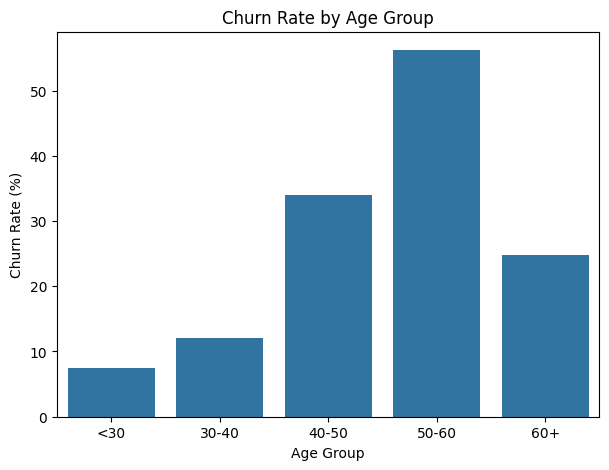

In [16]:
# Visualize churn rate by age group
plt.figure(figsize=(7, 5))

sns.barplot(
    x=Age_churn.index,
    y=Age_churn.values
)

plt.title("Churn Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Churn Rate (%)")

plt.show()

In [17]:
#segment analysis by age group and active membership status
segment_analysis = (
    df.groupby(["Age_group", "IsActiveMember"], observed=True)
      .agg(
          customers=("Exited", "size"),
          churn_rate=("Exited", "mean"),
          avg_balance=("Balance", "mean")
      )
      .reset_index()
)

segment_analysis["churn_rate"] = (
    segment_analysis["churn_rate"] * 100
).round(2)

segment_analysis["avg_balance"] = (
    segment_analysis["avg_balance"]
    .round(2)
)

segment_analysis

,Age_group,IsActiveMember,customers,churn_rate,avg_balance
0,<30,0,962,10.08,73173.45
1,<30,1,1006,5.07,73222.97
2,30-40,0,2236,14.94,74576.71
3,30-40,1,2215,9.21,76599.56
4,40-50,0,1226,41.60,80767.99
5,40-50,1,1094,25.41,77277.82
6,50-60,0,336,85.71,90452.25
7,50-60,1,461,34.71,76533.99
8,60+,0,89,82.02,83873.07
9,60+,1,375,11.20,73812.97


In [20]:
# Calculate estimated churned customers
segment_analysis["estimated_churned"] = (
    segment_analysis["customers"] *
    segment_analysis["churn_rate"] / 100
).round()

In [ ]:
# Sort the segment analysis by estimated churned customers in descending order
segment_analysis.sort_values(
    "estimated_churned",
    ascending=False
)

,Age_group,IsActiveMember,customers,churn_rate,avg_balance,estimated_churned
4,40-50,0,1226,41.60,80767.99,510.0
2,30-40,0,2236,14.94,74576.71,334.0
6,50-60,0,336,85.71,90452.25,288.0
5,40-50,1,1094,25.41,77277.82,278.0
3,30-40,1,2215,9.21,76599.56,204.0
7,50-60,1,461,34.71,76533.99,160.0
0,<30,0,962,10.08,73173.45,97.0
8,60+,0,89,82.02,83873.07,73.0
1,<30,1,1006,5.07,73222.97,51.0
9,60+,1,375,11.20,73812.97,42.0


In [ ]:
# Create a new column for plotting
plot_data = segment_analysis.copy()

plot_data["segment"] = (
    plot_data["Age_group"].astype(str)
    + " | "
    + plot_data["IsActiveMember"].map({
        0: "Inactive",
        1: "Active"
    })
)

plot_data = plot_data.sort_values(
    "estimated_churned",
    ascending=False
)

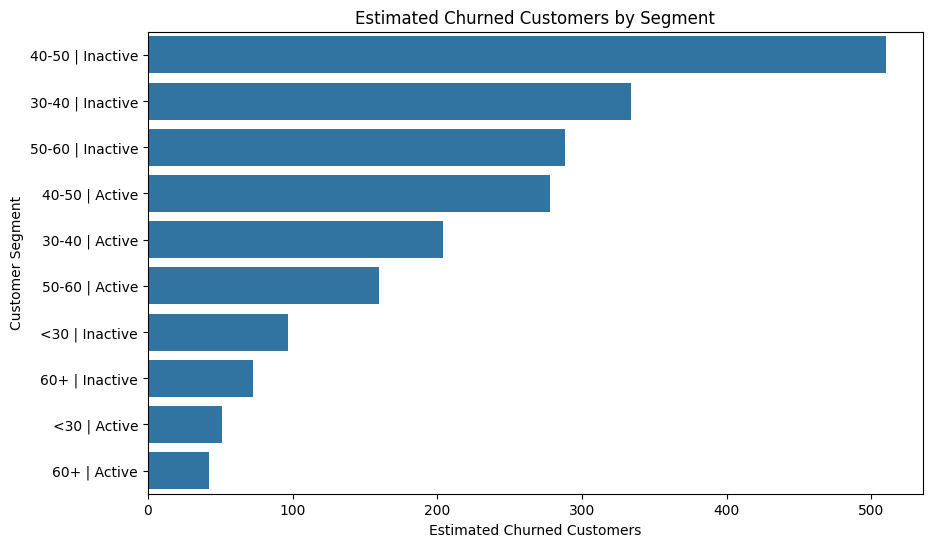

In [ ]:
# Visualize estimated churned customers by segment
plt.figure(figsize=(10, 6))

sns.barplot(
    data=plot_data,
    x="estimated_churned",
    y="segment"
)

plt.title("Estimated Churned Customers by Segment")
plt.xlabel("Estimated Churned Customers")
plt.ylabel("Customer Segment")

plt.show()

In [ ]:
# Create a dashboard-ready DataFrame
dashboard_segments = segment_analysis.copy()

dashboard_segments["Segment"] = (
    dashboard_segments["Age_group"].astype(str)
    + " - "
    + dashboard_segments["IsActiveMember"].map({
        0: "Inactive",
        1: "Active"
    })
)

dashboard_segments = dashboard_segments[
    [
        "Segment",
        "customers",
        "churn_rate",
        "estimated_churned",
        "avg_balance"
    ]
]

dashboard_segments = dashboard_segments.sort_values(
    "estimated_churned",
    ascending=False
)

dashboard_segments

,Segment,customers,churn_rate,estimated_churned,avg_balance
4,40-50 - Inactive,1226,41.60,510.0,80767.99
2,30-40 - Inactive,2236,14.94,334.0,74576.71
6,50-60 - Inactive,336,85.71,288.0,90452.25
5,40-50 - Active,1094,25.41,278.0,77277.82
3,30-40 - Active,2215,9.21,204.0,76599.56
7,50-60 - Active,461,34.71,160.0,76533.99
0,<30 - Inactive,962,10.08,97.0,73173.45
8,60+ - Inactive,89,82.02,73.0,83873.07
1,<30 - Active,1006,5.07,51.0,73222.97
9,60+ - Active,375,11.20,42.0,73812.97


In [ ]:
# Calculate overall churn rate and average balance
total_customers = len(df)

total_churned = df["Exited"].sum()

churn_rate = (
    df["Exited"].mean() * 100
).round(2)

avg_balance = df["Balance"].mean().round(2)

print("Total Customers:", total_customers)
print("Total Churned:", total_churned)
print("Overall Churn Rate:", churn_rate, "%")
print("Average Balance:", avg_balance)

Total Customers: 10000
Total Churned: 2037
Overall Churn Rate: 20.37 %
Average Balance: 76485.89


In [ ]:
# Save the dashboard segments to a CSV file 
dashboard_segments.to_csv(
    "customer_segments.csv",
    index=False
)

In [28]:
# Save the dashboard segments to a CSV file
dashboard_segments.to_csv(
    "customer_segments.csv",
    index=False
)

In [29]:
# Save the full dataset for the dashboard

df.to_csv(
    "bank_churn_dashboard.csv",
    index=False
)